# Feature Engineering 01: Direct Fusion Evidence

This notebook converts the reviewed DepMap 24Q4 filtered-fusion evidence into a small, explainable **pair-level feature table**. It does not train a model, rank pairs, or calculate a probability.

A fusion means parts of two genes were observed in the same RNA transcript. That is direct physical evidence for a connection, but it does not by itself prove that the transcript makes a working cancer-driving protein.

## Biological Question and Feature Contract

For an unordered pair such as `ALK--EML4`, how often was the exact filtered fusion observed, how well supported were the calls, and in which cancer lineages did it occur?

The output keeps these ideas separate: recurrence, junction-read support, spanning-fragment support, abundance, large-anchor support, and lineage concentration. No feature is a hidden driver-fusion score. Reading frame and retained protein domains are unavailable in this release and are intentionally not inferred.

**Grain:** one row per observed canonical unordered fusion pair. An unobserved pair is not added as a row of zeroes. Its fusion status must be evaluated at query time against the fusion-assayed model denominator.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        marker = candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv'
        if marker.exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
ARCHITECTURE = DATA / 'architecture'
DERIVED = DATA / 'derived'
OUTPUT_DIR = ARCHITECTURE / 'feature_engineering'
OUTPUT_DIR.mkdir(exist_ok=True)

PATHS = {
    'model_master': ARCHITECTURE / 'model_master.csv',
    'fusion_model_pair': ARCHITECTURE / 'fusion_pair_evidence.csv',
    'fusion_calls': DERIVED / 'fusions_filtered_model.csv',
    'pair_features': OUTPUT_DIR / 'direct_fusion_pair_features.csv',
    'quality_audit': OUTPUT_DIR / 'direct_fusion_feature_quality_audit.csv',
    'feature_manifest': OUTPUT_DIR / 'direct_fusion_feature_manifest.json',
}

master = pd.read_csv(PATHS['model_master'], low_memory=False)
model_pair = pd.read_csv(PATHS['fusion_model_pair'], low_memory=False)
fusion_calls = pd.read_csv(PATHS['fusion_calls'], low_memory=False)

print(f'Model master: {len(master):,} models')
print(f'Fusion model-pair evidence: {len(model_pair):,} rows')
print(f'Filtered fusion calls: {len(fusion_calls):,} rows')

Model master: 2,105 models
Fusion model-pair evidence: 39,842 rows
Filtered fusion calls: 50,008 rows


## Column Dictionary

| Input column or derived feature | Simple meaning | Why it is retained |
|---|---|---|
| `fusion_pair_id` | Alphabetically ordered pair of gene symbols. | Lets a user find a fusion in either gene order. |
| `model_id` | Stable DepMap identifier for one cell-line model. | The only automatic model-level join key. |
| `n_filtered_calls` | Calls for this pair inside one model. | Preserves repeated call evidence before pair aggregation. |
| `total_junction_reads` | Reads crossing the exact fusion boundary. | Direct technical support for the join. |
| `total_spanning_fragments` | Fragments supporting both sides of the join. | A second type of technical support. |
| `max_ffpm` | Largest fusion fragments per million in a model-pair record. | Relative fusion abundance, not proof of function. |
| `has_large_anchor_support` | Whether a call has sufficiently long sequence anchors. | Technical confidence context. |
| `models_with_fusion` | Distinct models with the exact pair. | Recurrence numerator. |
| `fusion_assayed_models` | Models eligible for the fusion assay. | Correct recurrence denominator. |
| `dominant_lineage_fraction` | Share of positive models in the most common lineage. | Describes disease concentration without calling it good or bad. |

## 1. Input Grain and Denominator Audit

The model-pair source must have at most one row for each `model_id` and `fusion_pair_id`. Recurrence is calculated against models with a fusion assay, not against only the models that happen to contain a fusion call.

In [2]:
required_master = {'model_id', 'oncotree_lineage', 'has_fusion_assay'}
required_pair = {
    'model_id', 'gene_a_symbol', 'gene_b_symbol', 'fusion_pair_id',
    'n_filtered_calls', 'total_junction_reads', 'total_spanning_fragments',
    'max_ffpm', 'has_large_anchor_support',
}
assert required_master.issubset(master.columns)
assert required_pair.issubset(model_pair.columns)
assert master['model_id'].is_unique
assert not model_pair.duplicated(['model_id', 'fusion_pair_id']).any()

assayed_models = master.loc[master['has_fusion_assay'].eq(1), ['model_id', 'oncotree_lineage']].copy()
assayed_model_ids = set(assayed_models['model_id'])
evidence_model_ids = set(model_pair['model_id'])

grain_audit = pd.DataFrame([{
    'all_models': len(master),
    'fusion_assayed_models': len(assayed_models),
    'fusion_model_pair_rows': len(model_pair),
    'models_with_observed_pair': model_pair['model_id'].nunique(),
    'evidence_models_outside_assay': len(evidence_model_ids - assayed_model_ids),
    'duplicate_model_pair_rows': int(model_pair.duplicated(['model_id', 'fusion_pair_id']).sum()),
}])
display(grain_audit)

assert not (evidence_model_ids - assayed_model_ids)
print('PASS: model-pair evidence has a valid model join and fusion-assay denominator.')

,all_models,fusion_assayed_models,fusion_model_pair_rows,models_with_observed_pair,evidence_models_outside_assay,duplicate_model_pair_rows
0,2105,1672,39842,1670,0,0


PASS: model-pair evidence has a valid model join and fusion-assay denominator.


### What this means for the project

A pair that has no row here was not observed in the retained fusion calls. That does not prove the pair cannot fuse. It means the current fusion assay did not report that pair among the tested models, so the dashboard must show the assay denominator instead of presenting a biological zero.

## 2. Build Route-Specific Features

The aggregation is deliberately transparent. We calculate counts, fractions, support summaries, and lineage context separately. We do not normalize and add them into one score.

In [3]:
pair_with_lineage = model_pair.merge(
    assayed_models, on='model_id', how='left', validate='many_to_one'
).copy()

pair_features = (
    pair_with_lineage.groupby(['fusion_pair_id', 'gene_a_symbol', 'gene_b_symbol'], dropna=False)
    .agg(
        models_with_fusion=('model_id', 'nunique'),
        filtered_calls_total=('n_filtered_calls', 'sum'),
        junction_reads_total=('total_junction_reads', 'sum'),
        junction_reads_median_per_model=('total_junction_reads', 'median'),
        spanning_fragments_total=('total_spanning_fragments', 'sum'),
        spanning_fragments_median_per_model=('total_spanning_fragments', 'median'),
        max_ffpm=('max_ffpm', 'max'),
        median_ffpm=('max_ffpm', 'median'),
        models_with_large_anchor=('has_large_anchor_support', 'sum'),
        lineages_with_fusion=('oncotree_lineage', 'nunique'),
    )
    .reset_index()
)

lineage_counts = (
    pair_with_lineage.dropna(subset=['oncotree_lineage'])
    .groupby(['fusion_pair_id', 'oncotree_lineage'])['model_id'].nunique()
    .rename('models_in_lineage')
    .reset_index()
    .sort_values(['fusion_pair_id', 'models_in_lineage', 'oncotree_lineage'], ascending=[True, False, True])
)
dominant_lineage = (
    lineage_counts.drop_duplicates('fusion_pair_id')
    .rename(columns={'oncotree_lineage': 'dominant_lineage', 'models_in_lineage': 'dominant_lineage_models'})
    [['fusion_pair_id', 'dominant_lineage', 'dominant_lineage_models']]
)

pair_features = pair_features.merge(dominant_lineage, on='fusion_pair_id', how='left', validate='one_to_one')
pair_features['fusion_assayed_models'] = len(assayed_models)
pair_features['fusion_model_fraction'] = pair_features['models_with_fusion'] / pair_features['fusion_assayed_models']
pair_features['large_anchor_fraction'] = pair_features['models_with_large_anchor'] / pair_features['models_with_fusion']
pair_features['dominant_lineage_fraction'] = (
    pair_features['dominant_lineage_models'] / pair_features['models_with_fusion']
)
pair_features['route_family'] = 'direct_fusion'
pair_features['source_release'] = master['release'].dropna().iloc[0]
pair_features['feature_status'] = 'measured_observed_pair'

feature_columns = [
    'fusion_pair_id', 'gene_a_symbol', 'gene_b_symbol', 'route_family', 'feature_status',
    'models_with_fusion', 'fusion_assayed_models', 'fusion_model_fraction',
    'filtered_calls_total', 'junction_reads_total', 'junction_reads_median_per_model',
    'spanning_fragments_total', 'spanning_fragments_median_per_model',
    'max_ffpm', 'median_ffpm', 'models_with_large_anchor', 'large_anchor_fraction',
    'lineages_with_fusion', 'dominant_lineage', 'dominant_lineage_models',
    'dominant_lineage_fraction', 'source_release',
]
pair_features = pair_features[feature_columns].sort_values(
    ['models_with_fusion', 'junction_reads_total', 'fusion_pair_id'], ascending=[False, False, True]
).reset_index(drop=True)

display(pair_features.head(15))

,fusion_pair_id,gene_a_symbol,gene_b_symbol,route_family,feature_status,models_with_fusion,fusion_assayed_models,fusion_model_fraction,filtered_calls_total,junction_reads_total,junction_reads_median_per_model,spanning_fragments_total,spanning_fragments_median_per_model,max_ffpm,median_ffpm,models_with_large_anchor,large_anchor_fraction,lineages_with_fusion,dominant_lineage,dominant_lineage_models,dominant_lineage_fraction,source_release
0,RPL37--RPL37P15,RPL37,RPL37P15,direct_fusion,measured_observed_pair,325,1672,0.194378,325,11716,32.0,0,0.0,1.6414,0.34590,325,1.000000,23,Lung,59.0,0.181538,DepMap 24Q4 Public
1,CAPNS1--FP236383.2,CAPNS1,FP236383.2,direct_fusion,measured_observed_pair,209,1672,0.125000,218,954,4.0,2046,7.0,0.5969,0.13060,206,0.985646,22,Lung,38.0,0.181818,DepMap 24Q4 Public
2,GAPDH--MT-ND4L,GAPDH,MT-ND4L,direct_fusion,measured_observed_pair,197,1672,0.117823,266,1073,4.0,1749,6.0,0.3206,0.10150,197,1.000000,21,Lung,47.0,0.238579,DepMap 24Q4 Public
3,AC126544.2--KANSL1,AC126544.2,KANSL1,direct_fusion,measured_observed_pair,184,1672,0.110048,238,1356,5.0,3369,11.5,1.3843,0.17605,183,0.994565,26,Lung,30.0,0.163043,DepMap 24Q4 Public
4,GAPDH--MT-ND4,GAPDH,MT-ND4,direct_fusion,measured_observed_pair,135,1672,0.080742,162,585,3.0,1591,8.0,0.4734,0.12580,134,0.992593,18,Lung,36.0,0.266667,DepMap 24Q4 Public
5,UBA52--UBB,UBA52,UBB,direct_fusion,measured_observed_pair,132,1672,0.078947,162,592,3.0,1480,9.0,0.4394,0.13045,131,0.992424,21,Lymphoid,28.0,0.212121,DepMap 24Q4 Public
6,AP000534.2--DUXAP10,AP000534.2,DUXAP10,direct_fusion,measured_observed_pair,120,1672,0.071770,127,1288,7.0,348,2.0,1.6687,0.09715,120,1.000000,23,Lung,25.0,0.208333,DepMap 24Q4 Public
7,APP--MT-CO3,APP,MT-CO3,direct_fusion,measured_observed_pair,115,1672,0.068780,125,585,4.0,634,4.0,0.3786,0.08760,115,1.000000,23,Lung,15.0,0.130435,DepMap 24Q4 Public
8,NCL--PTMA,NCL,PTMA,direct_fusion,measured_observed_pair,114,1672,0.068182,181,661,4.0,2577,13.0,0.5822,0.18230,113,0.991228,17,Lymphoid,34.0,0.298246,DepMap 24Q4 Public
9,MT-CO3--YBX1,MT-CO3,YBX1,direct_fusion,measured_observed_pair,108,1672,0.064593,108,501,4.0,299,3.0,0.2001,0.07115,108,1.000000,21,Ovary/Fallopian Tube,15.0,0.138889,DepMap 24Q4 Public


### What this means for the project

`fusion_model_fraction` tells us how common a pair was among fusion-assayed models. `junction_reads_total`, `spanning_fragments_total`, and `large_anchor_fraction` tell us how much technical support the observed calls had. `dominant_lineage` tells us where the pair was concentrated. None of these fields alone says that the pair is a validated cancer driver.

## 3. Feature Quality Checks and Visual Audit

,observed_fusion_pairs,pairs_seen_in_more_than_one_model,pairs_with_complete_large_anchor_support,pairs_missing_lineage_context,assayed_model_denominator
0,27256,2718,26273,2,1672


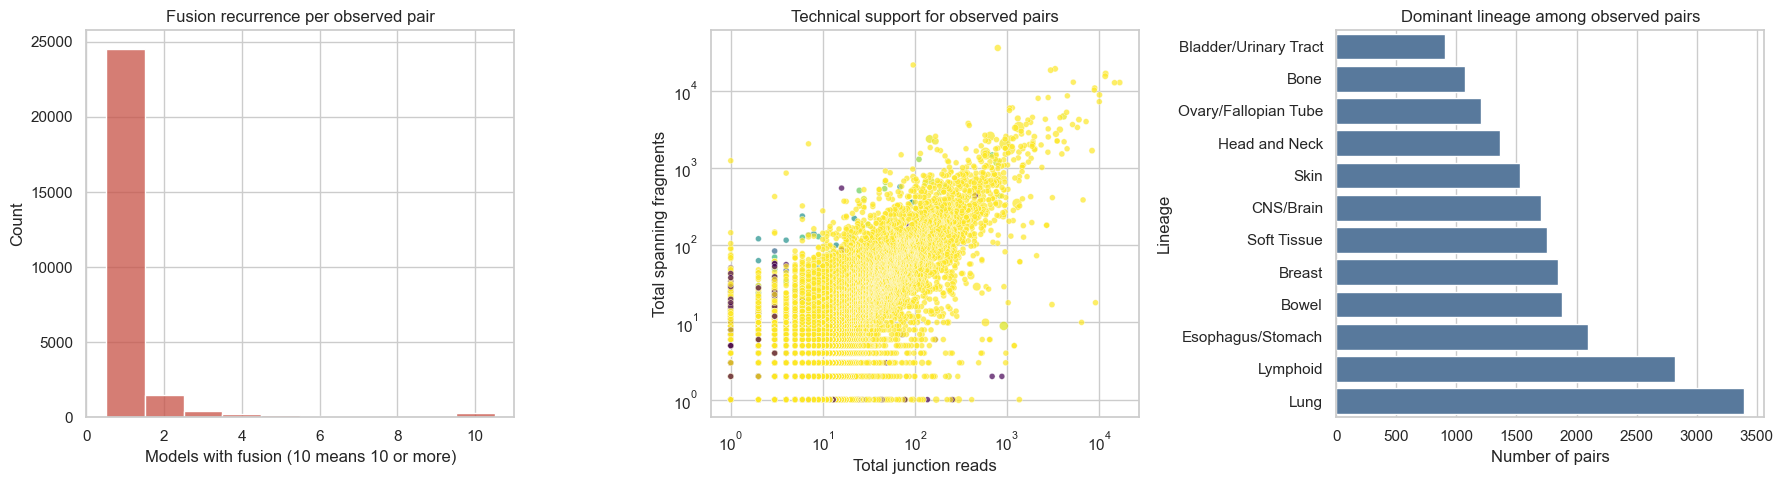

PASS: feature table has unique pairs, valid fractions, and a visible assay denominator.


In [4]:
assert pair_features['fusion_pair_id'].is_unique
assert pair_features['models_with_fusion'].le(pair_features['fusion_assayed_models']).all()
assert pair_features['fusion_model_fraction'].between(0, 1).all()
assert pair_features['large_anchor_fraction'].between(0, 1).all()
assert pair_features['dominant_lineage_fraction'].dropna().between(0, 1).all()

audit_summary = pd.DataFrame([{
    'observed_fusion_pairs': len(pair_features),
    'pairs_seen_in_more_than_one_model': int(pair_features['models_with_fusion'].gt(1).sum()),
    'pairs_with_complete_large_anchor_support': int(pair_features['large_anchor_fraction'].eq(1).sum()),
    'pairs_missing_lineage_context': int(pair_features['dominant_lineage'].isna().sum()),
    'assayed_model_denominator': len(assayed_models),
}])
display(audit_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(pair_features['models_with_fusion'].clip(upper=10), discrete=True, ax=axes[0], color='#c75146')
axes[0].set(title='Fusion recurrence per observed pair', xlabel='Models with fusion (10 means 10 or more)')

plot_data = pair_features.loc[
    pair_features['junction_reads_total'].gt(0) & pair_features['spanning_fragments_total'].gt(0)
].copy()
sns.scatterplot(
    data=plot_data, x='junction_reads_total', y='spanning_fragments_total',
    size='models_with_fusion', hue='large_anchor_fraction', palette='viridis',
    alpha=0.7, ax=axes[1], legend=False,
)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set(title='Technical support for observed pairs', xlabel='Total junction reads', ylabel='Total spanning fragments')

top_lineages = pair_features['dominant_lineage'].value_counts().head(12).sort_values()
sns.barplot(x=top_lineages.values, y=top_lineages.index, ax=axes[2], color='#4c78a8')
axes[2].set(title='Dominant lineage among observed pairs', xlabel='Number of pairs', ylabel='Lineage')
plt.tight_layout()
plt.show()

print('PASS: feature table has unique pairs, valid fractions, and a visible assay denominator.')

### What this means for the project

These plots are a review tool, not a ranking method. Very recurrent pairs and very high read counts deserve biological inspection, but they can still be passenger events or technically favoured calls. A pair concentrated in one lineage can be biologically sensible, especially for a known cancer subtype.

## 4. Mathematical Feature-Quality Audit

Fusion quality needs route-specific mathematics. Recurrence receives a Wilson interval, lineage sensitivity is measured by leaving out one eligible lineage at a time, and technical features are checked for redundancy. Lineage concentration is descriptive: a cancer-driving fusion can be correctly restricted to one disease lineage.

,feature_name,route_family,feature_role,pre_label_decision,non_missing_fraction,unique_values,most_correlated_feature,max_abs_spearman,redundancy_sample_size,biological_rationale,leakage_gate
0,models_with_fusion,direct_fusion,biological_route,keep_candidate,1.000000,75,fusion_model_fraction,1.000000,27256,Observed recurrence numerator.,pass
1,fusion_model_fraction,direct_fusion,display,supporting_only,1.000000,75,models_with_fusion,1.000000,27256,Exact transform of recurrence count because th...,pass
2,filtered_calls_total,direct_fusion,technical_confidence,supporting_only,1.000000,84,models_with_fusion,0.610427,27256,Repeated calls can track recurrence and requir...,pass
3,junction_reads_total,direct_fusion,technical_confidence,supporting_only,1.000000,637,junction_reads_median_per_model,0.945978,27256,Total support can rise with the number of posi...,pass
4,junction_reads_median_per_model,direct_fusion,technical_confidence,keep_candidate,1.000000,661,junction_reads_total,0.945978,27256,Robust typical junction support per positive m...,pass
5,spanning_fragments_total,direct_fusion,technical_confidence,supporting_only,1.000000,698,spanning_fragments_median_per_model,0.978455,27256,Total support can rise with recurrence.,pass
6,spanning_fragments_median_per_model,direct_fusion,technical_confidence,keep_candidate,1.000000,711,spanning_fragments_total,0.978455,27256,Robust typical spanning support per positive m...,pass
7,max_ffpm,direct_fusion,technical_confidence,supporting_only,1.000000,7180,median_ffpm,0.984731,27256,Strongest abundance can be driven by one model.,pass
8,median_ffpm,direct_fusion,technical_confidence,keep_candidate,1.000000,7648,max_ffpm,0.984731,27256,Typical abundance across positive models.,pass
9,models_with_large_anchor,direct_fusion,technical_confidence,supporting_only,1.000000,75,models_with_fusion,0.865805,27256,Count is partly determined by recurrence.,pass


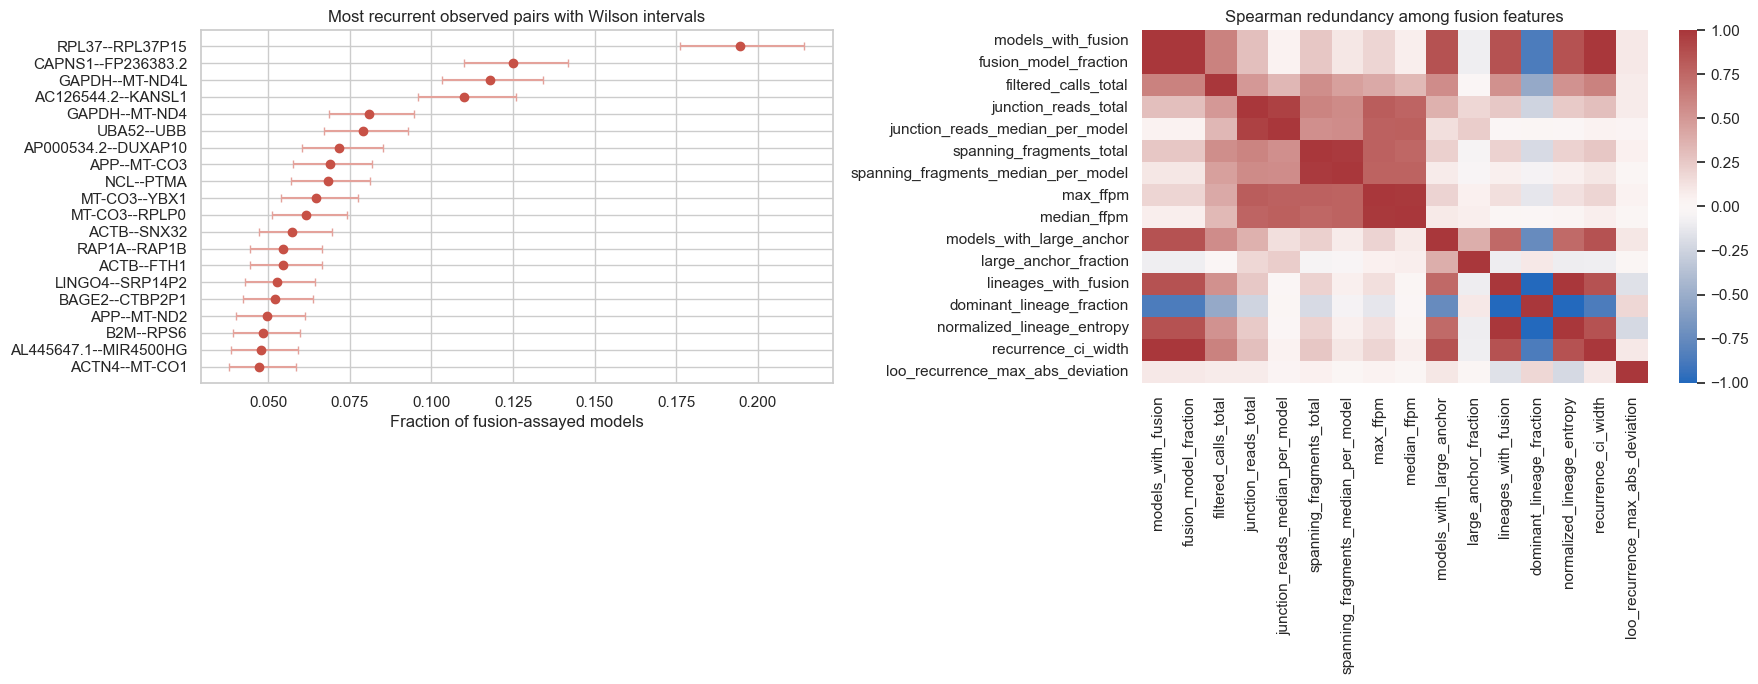

PASS: recurrence uncertainty, lineage sensitivity, entropy, and redundancy checks are valid.


In [5]:
def wilson_interval(successes: pd.Series, total: int, z: float = 1.96) -> tuple[pd.Series, pd.Series]:
    proportion = successes / total
    denominator = 1 + z**2 / total
    centre = (proportion + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt(proportion * (1 - proportion) / total + z**2 / (4 * total**2)) / denominator
    return (centre - margin).clip(lower=0), (centre + margin).clip(upper=1)

pair_features['recurrence_ci_low'], pair_features['recurrence_ci_high'] = wilson_interval(
    pair_features['models_with_fusion'], len(assayed_models)
)
pair_features['recurrence_ci_width'] = pair_features['recurrence_ci_high'] - pair_features['recurrence_ci_low']

def normalized_lineage_entropy(counts: pd.Series) -> float:
    probabilities = counts / counts.sum()
    if len(probabilities) <= 1:
        return 0.0
    entropy = -(probabilities * np.log(probabilities)).sum() / np.log(len(probabilities))
    return float(np.clip(entropy, 0.0, 1.0))

lineage_entropy = (
    lineage_counts.groupby('fusion_pair_id')['models_in_lineage']
    .apply(normalized_lineage_entropy)
    .rename('normalized_lineage_entropy')
    .reset_index()
)
pair_features = pair_features.merge(lineage_entropy, on='fusion_pair_id', how='left', validate='one_to_one')
pair_features['normalized_lineage_entropy'] = pair_features['normalized_lineage_entropy'].fillna(0)

assayed_lineage_counts = assayed_models['oncotree_lineage'].value_counts()
eligible_loo_lineages = assayed_lineage_counts[assayed_lineage_counts >= 15].index.tolist()
pair_lineage_lookup = {
    pair_id: dict(zip(group['oncotree_lineage'], group['models_in_lineage']))
    for pair_id, group in lineage_counts.groupby('fusion_pair_id')
}

def recurrence_without_each_lineage(row: pd.Series) -> tuple[float, float, float]:
    baseline = row['fusion_model_fraction']
    positive_counts = pair_lineage_lookup.get(row['fusion_pair_id'], {})
    values = []
    for lineage in eligible_loo_lineages:
        remaining_total = len(assayed_models) - int(assayed_lineage_counts[lineage])
        remaining_positive = row['models_with_fusion'] - int(positive_counts.get(lineage, 0))
        values.append(remaining_positive / remaining_total)
    return min(values), max(values), max(abs(value - baseline) for value in values)

loo_values = pair_features.apply(recurrence_without_each_lineage, axis=1, result_type='expand')
loo_values.columns = ['loo_recurrence_min', 'loo_recurrence_max', 'loo_recurrence_max_abs_deviation']
pair_features = pd.concat([pair_features, loo_values], axis=1)

audited_numeric_features = [
    'models_with_fusion', 'fusion_model_fraction', 'filtered_calls_total',
    'junction_reads_total', 'junction_reads_median_per_model',
    'spanning_fragments_total', 'spanning_fragments_median_per_model',
    'max_ffpm', 'median_ffpm', 'models_with_large_anchor', 'large_anchor_fraction',
    'lineages_with_fusion', 'dominant_lineage_fraction', 'normalized_lineage_entropy',
    'recurrence_ci_width', 'loo_recurrence_max_abs_deviation',
]
redundancy_matrix = pair_features[audited_numeric_features].corr(method='spearman')

feature_roles = {
    'models_with_fusion': ('biological_route', 'keep_candidate', 'Observed recurrence numerator.'),
    'fusion_model_fraction': ('display', 'supporting_only', 'Exact transform of recurrence count because the denominator is fixed.'),
    'filtered_calls_total': ('technical_confidence', 'supporting_only', 'Repeated calls can track recurrence and require visible interpretation.'),
    'junction_reads_total': ('technical_confidence', 'supporting_only', 'Total support can rise with the number of positive models.'),
    'junction_reads_median_per_model': ('technical_confidence', 'keep_candidate', 'Robust typical junction support per positive model.'),
    'spanning_fragments_total': ('technical_confidence', 'supporting_only', 'Total support can rise with recurrence.'),
    'spanning_fragments_median_per_model': ('technical_confidence', 'keep_candidate', 'Robust typical spanning support per positive model.'),
    'max_ffpm': ('technical_confidence', 'supporting_only', 'Strongest abundance can be driven by one model.'),
    'median_ffpm': ('technical_confidence', 'keep_candidate', 'Typical abundance across positive models.'),
    'models_with_large_anchor': ('technical_confidence', 'supporting_only', 'Count is partly determined by recurrence.'),
    'large_anchor_fraction': ('technical_confidence', 'keep_candidate', 'Normalises anchor support by positive models.'),
    'lineages_with_fusion': ('biological_explanation', 'supporting_only', 'Describes disease spread, not universal quality.'),
    'dominant_lineage_fraction': ('biological_explanation', 'supporting_only', 'Describes lineage concentration without penalising specificity.'),
    'normalized_lineage_entropy': ('biological_explanation', 'supporting_only', 'Describes distribution across positive lineages.'),
    'recurrence_ci_width': ('confidence_context', 'confidence_only', 'Quantifies recurrence uncertainty.'),
    'loo_recurrence_max_abs_deviation': ('confidence_context', 'confidence_only', 'Shows sensitivity to excluding one eligible lineage.'),
}

audit_rows = []
for feature_name in audited_numeric_features:
    other_correlations = redundancy_matrix[feature_name].drop(feature_name).abs().dropna()
    most_correlated = other_correlations.idxmax() if not other_correlations.empty else pd.NA
    role, decision, rationale = feature_roles[feature_name]
    audit_rows.append({
        'feature_name': feature_name,
        'route_family': 'direct_fusion',
        'feature_role': role,
        'pre_label_decision': decision,
        'non_missing_fraction': pair_features[feature_name].notna().mean(),
        'unique_values': pair_features[feature_name].nunique(dropna=True),
        'most_correlated_feature': most_correlated,
        'max_abs_spearman': other_correlations.max() if not other_correlations.empty else np.nan,
        'redundancy_sample_size': pair_features[[feature_name, most_correlated]].dropna().shape[0] if pd.notna(most_correlated) else 0,
        'biological_rationale': rationale,
        'leakage_gate': 'pass',
    })
feature_quality_audit = pd.DataFrame(audit_rows)
display(feature_quality_audit)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top_recurrent = pair_features.nlargest(20, 'models_with_fusion').sort_values('fusion_model_fraction')
axes[0].errorbar(
    top_recurrent['fusion_model_fraction'], np.arange(len(top_recurrent)),
    xerr=[top_recurrent['fusion_model_fraction'] - top_recurrent['recurrence_ci_low'], top_recurrent['recurrence_ci_high'] - top_recurrent['fusion_model_fraction']],
    fmt='o', color='#c75146', ecolor='#e4a29b', capsize=3,
)
axes[0].set_yticks(np.arange(len(top_recurrent)), top_recurrent['fusion_pair_id'])
axes[0].set_title('Most recurrent observed pairs with Wilson intervals')
axes[0].set_xlabel('Fraction of fusion-assayed models')
sns.heatmap(redundancy_matrix, cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman redundancy among fusion features')
plt.tight_layout(); plt.show()

quality_fields = [
    'recurrence_ci_low', 'recurrence_ci_high', 'recurrence_ci_width',
    'normalized_lineage_entropy', 'loo_recurrence_min', 'loo_recurrence_max',
    'loo_recurrence_max_abs_deviation',
]
feature_columns.extend(quality_fields)
assert pair_features['recurrence_ci_low'].le(pair_features['fusion_model_fraction']).all()
assert pair_features['recurrence_ci_high'].ge(pair_features['fusion_model_fraction']).all()
assert pair_features['normalized_lineage_entropy'].between(0, 1).all()
print('PASS: recurrence uncertainty, lineage sensitivity, entropy, and redundancy checks are valid.')

### What this means for the project

The audit identifies which values measure fusion biology and which only describe measurement confidence. It also shows that `models_with_fusion` and `fusion_model_fraction` contain the same ranking information while the denominator is fixed, so both should not be treated as independent model features. High lineage sensitivity is displayed, not automatically rejected, because real cancer fusions can be disease-specific.

## 5. Known-Example Lookup

Known examples test that canonical lookup works in either order. They do not validate the project outcome or label every observed pair as functional.

In [6]:
def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([gene_a.strip().upper(), gene_b.strip().upper()]))

examples = [('EML4', 'ALK'), ('BCR', 'ABL1'), ('TMPRSS2', 'ERG')]
example_pairs = [canonical_pair(gene_a, gene_b) for gene_a, gene_b in examples]
example_review = pair_features.loc[pair_features['fusion_pair_id'].isin(example_pairs)].copy()
display(example_review)

for gene_a, gene_b in examples:
    forward = canonical_pair(gene_a, gene_b)
    reverse = canonical_pair(gene_b, gene_a)
    assert forward == reverse
print('PASS: fusion lookup is order-independent for example pairs.')

,fusion_pair_id,gene_a_symbol,gene_b_symbol,route_family,feature_status,models_with_fusion,fusion_assayed_models,fusion_model_fraction,filtered_calls_total,junction_reads_total,junction_reads_median_per_model,spanning_fragments_total,spanning_fragments_median_per_model,max_ffpm,median_ffpm,models_with_large_anchor,large_anchor_fraction,lineages_with_fusion,dominant_lineage,dominant_lineage_models,dominant_lineage_fraction,source_release,recurrence_ci_low,recurrence_ci_high,recurrence_ci_width,normalized_lineage_entropy,loo_recurrence_min,loo_recurrence_max,loo_recurrence_max_abs_deviation
94,ABL1--BCR,ABL1,BCR,direct_fusion,measured_observed_pair,24,1672,0.014354,52,3768,151.0,3134,115.5,7.9447,2.2343,24,1.0,2,Myeloid,20.0,0.833333,DepMap 24Q4 Public,0.009665,0.021270,0.011605,0.650022,0.002503,0.016461,0.011851
352,ALK--EML4,ALK,EML4,direct_fusion,measured_observed_pair,7,1672,0.004187,13,331,36.0,615,71.0,2.0730,1.1472,7,1.0,4,Lung,4.0,0.571429,DepMap 24Q4 Public,0.002029,0.008617,0.006587,0.832249,0.002058,0.004711,0.002129
1281,ERG--TMPRSS2,ERG,TMPRSS2,direct_fusion,measured_observed_pair,2,1672,0.001196,5,413,206.5,133,66.5,2.5995,1.3715,2,1.0,1,Prostate,2.0,1.000000,DepMap 24Q4 Public,0.000328,0.004351,0.004023,0.000000,0.001211,0.001372,0.000176


PASS: fusion lookup is order-independent for example pairs.


## 6. Export and Feature Manifest

The CSV is a route-specific derived table, not a master-table expansion. The JSON manifest records the input files, grain, denominator rule, feature meanings, and exclusions needed for an audit.

In [7]:
pair_features.to_csv(PATHS['pair_features'], index=False)
feature_quality_audit.to_csv(PATHS['quality_audit'], index=False)

manifest = {
    'feature_table': str(PATHS['pair_features'].relative_to(PROJECT_ROOT)),
    'feature_quality_audit': str(PATHS['quality_audit'].relative_to(PROJECT_ROOT)),
    'grain': 'one row per observed canonical unordered fusion pair',
    'route_family': 'direct_fusion',
    'source_release': master['release'].dropna().iloc[0],
    'input_files': [str(PATHS['model_master'].relative_to(PROJECT_ROOT)), str(PATHS['fusion_model_pair'].relative_to(PROJECT_ROOT))],
    'denominator_rule': 'fusion_model_fraction uses models with has_fusion_assay == 1',
    'missingness_rule': 'an unobserved pair is not encoded as a biological zero; query-time absence is interpreted only inside the fusion-assayed cohort',
    'included_features': feature_columns,
    'not_inferred': ['reading frame', 'retained protein domains', 'driver status', 'protein activity'],
    'row_count': int(len(pair_features)),
    'fusion_assayed_models': int(len(assayed_models)),
}
PATHS['feature_manifest'].write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print(f'Wrote {len(pair_features):,} feature rows to {PATHS["pair_features"]}')
print(f'Wrote manifest to {PATHS["feature_manifest"]}')

Wrote 27,256 feature rows to data\depmap_24Q4\architecture\feature_engineering\direct_fusion_pair_features.csv
Wrote manifest to data\depmap_24Q4\architecture\feature_engineering\direct_fusion_feature_manifest.json


## Decision Carried Forward

Direct-fusion features are ready as one transparent evidence module. They should remain separate from CRISPR codependency and conditional dependency when the next notebooks are built. PRISM, TCGA, Reactome, STRING, and BioGRID can later explain or validate a finding, but they do not change these measured fusion values.